## Partie 3 — Évaluation, interprétabilité & application finale

### 1. Évaluation avancée


#### Matrice de confusion


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [2]:
def confusion_matrix(y_true, y_pred):
    """
    Compute the confusion matrix for binary classification.

    Parameters:
    y_true (list): True labels (0 or 1).
    y_pred (list): Predicted labels (0 or 1).

    Returns:
    dict: A dictionary containing TP, TN, FP, and FN.
    """
    TP = sum((y_true[i] == 1 and y_pred[i] == 1) for i in range(len(y_true)))
    TN = sum((y_true[i] == 0 and y_pred[i] == 0) for i in range(len(y_true)))
    FP = sum((y_true[i] == 0 and y_pred[i] == 1) for i in range(len(y_true)))
    FN = sum((y_true[i] == 1 and y_pred[i] == 0) for i in range(len(y_true)))

    return {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN}

def accuracy(conf_matrix):
    """
    Compute the accuracy from the confusion matrix.

    Parameters:
    conf_matrix (dict): A dictionary containing TP, TN, FP, and FN.

    Returns:
    float: The accuracy value.
    """
    TP = conf_matrix['TP']
    TN = conf_matrix['TN']
    FP = conf_matrix['FP']
    FN = conf_matrix['FN']
    
    total = TP + TN + FP + FN
    if total == 0:
        return 0.0  # Avoid division by zero
    return (TP + TN) / total

def precision(conf_matrix):
    """
    Compute the precision from the confusion matrix.

    Parameters:
    conf_matrix (dict): A dictionary containing TP, TN, FP, and FN.

    Returns:
    float: The precision value.
    """
    TP = conf_matrix['TP']
    FP = conf_matrix['FP']
    
    if TP + FP == 0:
        return 0.0  # Avoid division by zero
    return TP / (TP + FP)
    
def recall(conf_matrix):
    """
    Compute the recall from the confusion matrix.

    Parameters:
    conf_matrix (dict): A dictionary containing TP, TN, FP, and FN.

    Returns:
    float: The recall value.
    """
    TP = conf_matrix['TP']
    FN = conf_matrix['FN']
    
    if TP + FN == 0:
        return 0.0  # Avoid division by zero
    return TP / (TP + FN)

def f1_score(precision_value, recall_value):
    """
    Compute the F1 score from precision and recall.

    Parameters:
    precision_value (float): The precision value.
    recall_value (float): The recall value.

    Returns:
    float: The F1 score.
    """
    if precision_value + recall_value == 0:
        return 0.0  # Avoid division by zero
    return 2 * (precision_value * recall_value) / (precision_value + recall_value)

# Example usage:
y_true = [0, 1, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1]
conf_matrix = confusion_matrix(y_true, y_pred)
acc = accuracy(conf_matrix)
prec = precision(conf_matrix)
rec = recall(conf_matrix)
f1 = f1_score(prec, rec)

print(f"Confusion Matrix: {conf_matrix}")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1 Score: {f1}")

Confusion Matrix: {'TP': 2, 'TN': 2, 'FP': 0, 'FN': 1}
Accuracy: 0.8
Precision: 1.0
Recall: 0.6666666666666666
F1 Score: 0.8


Matrice de confusion normalisée


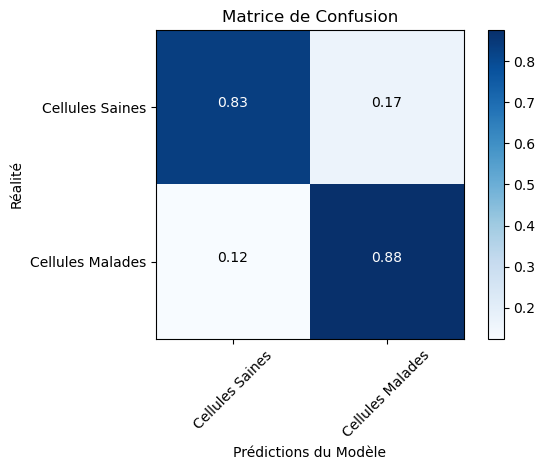

In [3]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Matrice de Confusion', cmap=plt.cm.Blues):
    """
    Cette fonction affiche la matrice de confusion.
    Normalisation peut être appliquée en définissant `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Matrice de confusion normalisée")
    else:
        print('Matrice de confusion, sans normalisation')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Réalité')
    plt.xlabel('Prédictions du Modèle')
    plt.tight_layout()

# Exemple d'utilisation
cm = np.array([[50, 10], [5, 35]])  # Exemple de matrice de confusion
classes = ['Cellules Saines', 'Cellules Malades']
plot_confusion_matrix(cm, classes, normalize=True)
plt.show()

#### ROC-AUC

In [4]:
def roc_auc(y_true, y_scores):
    """
    Calcule le score ROC AUC en utilisant la vectorisation NumPy.
    """
    # Convertir en tableaux NumPy pour la vectorisation
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    
    # 1. Séparer les scores via des masques booléens
    pos_scores = y_scores[y_true == 1]
    neg_scores = y_scores[y_true == 0]
    
    if len(pos_scores) == 0 or len(neg_scores) == 0:
        raise ValueError("Il faut au moins un exemple de la classe 0 et de la classe 1.")
        
    # 2. Calculer les différences de scores entre les positifs et les négatifs
    # On transforme pos_scores en colonne et on soustrait neg_scores (ligne).
    # Cela crée instantanément une matrice comparant chaque positif à chaque négatif.
    diff = pos_scores[:, np.newaxis] - neg_scores
    
    # 3. Compter les paires concordantes et les égalités
    concordant_pairs = np.sum(diff > 0)
    ties = np.sum(diff == 0) * 0.5
    
    # 4. Calcul final
    total_pairs = len(pos_scores) * len(neg_scores)
    auc = (concordant_pairs + ties) / total_pairs
    
    return auc

# --- Exemple d'utilisation ---
y_true = [0, 0, 1, 1]
y_scores = [0.1, 0.4, 0.35, 0.8]

auc_score = roc_auc(y_true, y_scores)
print(f"ROC AUC Score (NumPy) : {auc_score}")

ROC AUC Score (NumPy) : 0.75


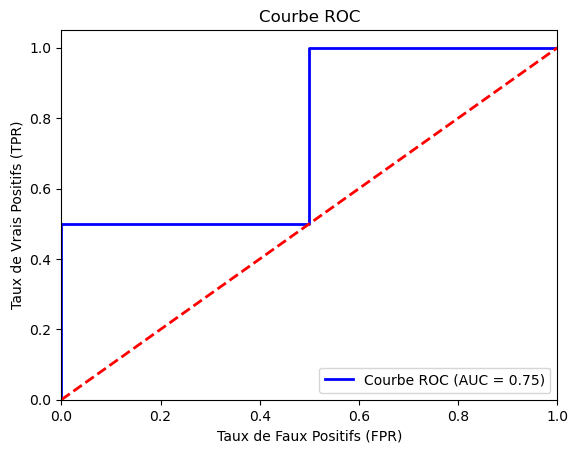

In [7]:
def roc_curve(y_true, y_scores):
    """
    Calcule les points (FPR, TPR) de la courbe ROC sans scikit-learn.
    """
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    
    # 1. Trier les scores par ordre décroissant
    # np.argsort renvoie les index qui trieraient le tableau. [::-1] inverse l'ordre pour l'avoir en décroissant.
    desc_score_indices = np.argsort(y_scores)[::-1]
    y_scores_sorted = y_scores[desc_score_indices]
    y_true_sorted = y_true[desc_score_indices]
    
    # Nombre total de positifs et de négatifs réels
    total_positives = np.sum(y_true == 1)
    total_negatives = np.sum(y_true == 0)
    
    # Listes pour stocker les coordonnées des points de la courbe (on commence à 0,0)
    tpr_list = [0.0]
    fpr_list = [0.0]
    thresholds = [y_scores_sorted[0] + 0.1] # Un seuil artificiel supérieur au max
    
    tp = 0
    fp = 0
    
    # 2. Balayer chaque score et l'utiliser comme seuil
    for i in range(len(y_scores_sorted)):
        # Si la vraie valeur à ce seuil est 1, on gagne un Vrai Positif
        if y_true_sorted[i] == 1:
            tp += 1
        # Sinon, c'est une fausse alerte, on gagne un Faux Positif
        else:
            fp += 1
            
        # 3. Ne sauvegarder le point que si le prochain score est différent (gère les ex-aequo)
        if i == len(y_scores_sorted) - 1 or y_scores_sorted[i] != y_scores_sorted[i+1]:
            tpr_list.append(tp / total_positives)
            fpr_list.append(fp / total_negatives)
            thresholds.append(y_scores_sorted[i])
            
    return np.array(fpr_list), np.array(tpr_list), np.array(thresholds)

# --- Exemple d'utilisation avec ton plot ---
y_true = [0, 0, 1, 1]
y_scores = [0.1, 0.4, 0.35, 0.8]

# On utilise notre fonction maison à la place de scikit-learn
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# On calcule l'AUC (en réutilisant la logique d'avant, ou la méthode mathématique des trapèzes)
# Pour simplifier l'affichage ici, on utilise numpy.trapz qui calcule l'aire sous une courbe
auc_score = np.trapezoid(tpr, fpr)

# Affichage (identique à ton code)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Courbe ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--') # La diagonale du hasard
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc="lower right")
plt.show()

# Exemple d'utilisation
y_true = [0, 0, 1, 1]
y_scores = [0.1, 0.4, 0.35, 0.8]  # Probabilités prédites pour la classe positive
roc_curve(y_true, y_scores)
plt.close("all")

In [11]:
def evaluer_modele_avec_seuil(y_vrai, y_scores, seuil=0.5):
    """
    Transforme les probabilités en décisions binaires selon un seuil, 
    puis calcule toutes les métriques.
    """
    y_scores = np.asarray(y_scores)
    
    # 1. La règle de décision : on transforme les probas en 0 ou 1
    # astype(int) transforme les True/False en 1/0
    y_pred_binaire = (y_scores >= seuil).astype(int) 
    
    # 2. Appel de tes fonctions existantes
    matrice = confusion_matrix(y_vrai, y_pred_binaire)
    acc = accuracy(matrice)
    prec = precision(matrice)
    rec = recall(matrice)
    f1 = f1_score(prec, rec)
    
    return matrice, acc, prec, rec, f1

def trouver_seuil_medical(y_vrai, y_scores, rappel_minimum_vise=0.95):
    """
    Cherche le seuil optimal pour garantir un niveau de rappel précis.
    """
    # On génère une liste de seuils à tester : 0.01, 0.02, 0.03... jusqu'à 0.99
    seuils_a_tester = np.arange(0.01, 1.0, 0.01)
    
    meilleur_seuil = 0.5
    meilleure_precision_trouvee = 0.0
    rappel_final = 0.0
    
    for seuil in seuils_a_tester:
        # On teste ce seuil
        _, _, prec, rec, _ = evaluer_modele_avec_seuil(y_vrai, y_scores, seuil)
        
        # Filtre 1 : Le seuil permet-il d'atteindre notre cible médicale de rappel ?
        if rec >= rappel_minimum_vise:
            # Filtre 2 : Parmi les seuils valides, on cherche celui qui a la meilleure précision
            if prec >= meilleure_precision_trouvee:
                meilleure_precision_trouvee = prec
                meilleur_seuil = seuil
                rappel_final = rec
                
    return meilleur_seuil, rappel_final, meilleure_precision_trouvee

# --- Test de la recherche de seuil ---
# Imaginons 10 cellules (5 saines, 5 infectées) et les scores de notre modèle
y_reel_test = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
# Le modèle est un peu incertain sur certains malades (scores à 0.3 ou 0.4)
y_scores_test = [0.1, 0.2, 0.05, 0.6, 0.3, 0.9, 0.8, 0.4, 0.35, 0.95] 

# Quel seuil pour être sûr de détecter 100% des malades ?
seuil_opt, rappel_opt, prec_opt = trouver_seuil_medical(y_reel_test, y_scores_test, rappel_minimum_vise=1.0)

print(f"Pour détecter 100% des malades, le seuil optimal est : {seuil_opt:.2f}")
print(f"Avec ce seuil, le Rappel est de {rappel_opt*100:.0f}%")
print(f"Et la Précision est de {prec_opt*100:.0f}%")

Pour détecter 100% des malades, le seuil optimal est : 0.34
Avec ce seuil, le Rappel est de 100%
Et la Précision est de 83%
